# Homework 3 — KNN Research
Dataset: Iris


## 1. Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

## 2. Load dataset

In [2]:
data = load_iris()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 3. Basic analysis

In [3]:
X.shape

(150, 4)

In [4]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [5]:
X.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
y.value_counts()

0    50
1    50
2    50
Name: count, dtype: int64

## 4. Train/test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 5. Feature scaling

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Train KNN model

In [9]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

pred = knn.predict(X_test_scaled)

accuracy_score(y_test, pred)

0.9333333333333333

## 7. Explore different k values

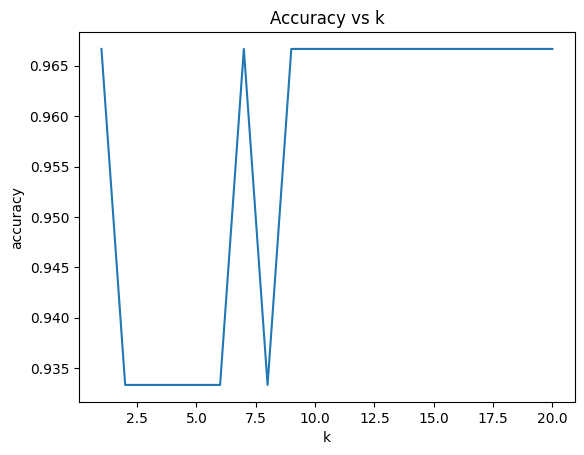

In [10]:
scores = []

k_values = range(1, 21)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    scores.append(accuracy_score(y_test, pred))

plt.plot(k_values, scores)
plt.xlabel('k')
plt.ylabel('accuracy')
plt.title('Accuracy vs k')
plt.show()

## 8. Distance metrics comparison

In [11]:
metrics = ['euclidean', 'manhattan', 'minkowski']

for m in metrics:
    model = KNeighborsClassifier(n_neighbors=5, metric=m)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)

    print(m, accuracy_score(y_test, pred))

euclidean 0.9333333333333333
manhattan 0.9333333333333333
minkowski 0.9333333333333333


## 9. Hyperparameter tuning

In [12]:
param_grid = {
    'n_neighbors': range(1,21),
    'weights': ['uniform','distance'],
    'metric': ['euclidean','manhattan','minkowski']
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train_scaled, y_train)

grid.best_params_

{'metric': 'euclidean', 'n_neighbors': 17, 'weights': 'distance'}

## 10. Final model evaluation

In [13]:
best_model = grid.best_estimator_

pred = best_model.predict(X_test_scaled)

accuracy_score(y_test, pred)

0.9666666666666667

In [14]:
confusion_matrix(y_test, pred)

array([[10,  0,  0],
       [ 0,  9,  1],
       [ 0,  0, 10]])